# 03 ? Public Replication on Taiwan Bankruptcy Data

Replicates the churn study's two headline findings on a public, fully reproducible, **cross-sectional** dataset (Taiwan company bankruptcy prediction ? one row per company, no repeated time-lag structure):

- **E1 analog** (notebook 01): does resampling before splitting inflate measured performance the same way the leaky `N`/`N-1` window did?
- **E2 analog** (notebook 02): does synthetic oversampling hurt ranking here the way it did on the churn panel?

This notebook tests the **neutral-vs-harmful demarcation** on a second dataset: SMOTE-style oversampling was harmful on the churn panel, while the Taiwan cross-sectional benchmark is neutral. With only two datasets, this is evidence of structure-dependent behavior, not proof that temporal structure is the mechanism.

All logic lives in `src/`; this notebook only orchestrates calls, displays results, and writes the verification report. No private data is used anywhere in this notebook.

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "README.md").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import FIGURES_DIR, OUTPUT_DIR, SEED, set_global_seed
from src.data.taiwan import download_taiwan, load_taiwan
from src.evaluation.strategies import STRATEGIES
from src.evaluation.leakage_demo import leaky_vs_honest_smote
from src.evaluation.cv import repeated_cv_xy
from src.evaluation.stats import paired_compare
from src.visualization.plots import plot_cross_dataset_delta_bar

TAIWAN_FIGURES_DIR = FIGURES_DIR / "taiwan_replication"
N_SPLITS = 5
N_REPEATS = 3
E2_STRATEGIES = [name for name in STRATEGIES if name != "smotenc"]  # no categoricals here

set_global_seed()
taiwan_path = download_taiwan()
X, y = load_taiwan(taiwan_path)
print(f"Loaded {len(X):,} rows x {X.shape[1]} columns from {taiwan_path}")
print(f"Positive rate: {y.mean():.6f}")

Loaded 6,819 rows x 95 columns from C:\Users\hpdk1\Documents\Projects\thesis-recreation-2026\data\raw\taiwan_bankruptcy.csv
Positive rate: 0.032263


## 1. E1 analog - SMOTE-before-split vs SMOTE-inside-fold

Same leakage mechanism as notebook 01's `N`/`N-1` window, but here induced by resampling protocol instead of a contaminated feature window: resample the whole dataset once (wrong) vs resample the training fold only (honest).

In [2]:
e1_result = leaky_vs_honest_smote(X, y, n_splits=N_SPLITS, seed=SEED)
print(e1_result)

{'leaky_pr_auc': 0.9995767539666236, 'honest_pr_auc': 0.4845789854244453, 'inflation': 0.5149977685421783}


## 2. E2 analog - imbalance strategy comparison

In [3]:
import time

fold_results = {}
for name in E2_STRATEGIES:
    t0 = time.time()
    fold_results[name] = repeated_cv_xy(
        X, y, name, n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=SEED
    )
    print(f"{name}: {len(fold_results[name])} folds in {time.time() - t0:.1f}s")

none: 15 folds in 59.4s


class_weight: 15 folds in 471.7s


random_over: 15 folds in 42.1s


smote: 15 folds in 51.5s


adasyn: 15 folds in 50.1s


random_under: 15 folds in 13.1s


In [4]:
METRIC_COLUMNS = ["pr_auc", "roc_auc", "recall_at_10pct", "brier"]

summary_rows = []
for name, folds in fold_results.items():
    row = {"strategy": name}
    for metric in METRIC_COLUMNS:
        row[f"{metric}_mean"] = float(folds[metric].mean())
        row[f"{metric}_std"] = float(folds[metric].std())
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index("strategy")

formatted_summary = pd.DataFrame(index=summary_df.index)
for metric in METRIC_COLUMNS:
    formatted_summary[metric] = (
        summary_df[f"{metric}_mean"].map("{:.6f}".format)
        + " \u00b1 "
        + summary_df[f"{metric}_std"].map("{:.6f}".format)
    )
display(formatted_summary)

,pr_auc,roc_auc,recall_at_10pct,brier
strategy,,,,
none,0.498675 ± 0.059632,0.936457 ± 0.016739,0.772727 ± 0.064282,0.025287 ± 0.001995
class_weight,0.507538 ± 0.068168,0.934793 ± 0.016705,0.766667 ± 0.075116,0.024673 ± 0.003254
random_over,0.489699 ± 0.075507,0.936505 ± 0.016509,0.774242 ± 0.063396,0.025730 ± 0.003804
smote,0.489610 ± 0.066658,0.938106 ± 0.012623,0.768182 ± 0.059638,0.028328 ± 0.003795
adasyn,0.491410 ± 0.077298,0.939784 ± 0.012007,0.775758 ± 0.073828,0.028598 ± 0.003899
random_under,0.379686 ± 0.052887,0.933314 ± 0.011424,0.757576 ± 0.058682,0.131076 ± 0.013308


## 3. Paired significance vs `none`

Per-fold paired comparison of PR-AUC (Wilcoxon signed-rank + paired t-test) for `smote` and `adasyn` against the `none` baseline.

In [5]:
none_pr_auc = fold_results["none"]["pr_auc"].to_numpy()
sig_rows = []
for name in ["smote", "adasyn"]:
    cmp = paired_compare(fold_results[name]["pr_auc"].to_numpy(), none_pr_auc)
    sig_rows.append({"strategy": name, **cmp})
sig_df = pd.DataFrame(sig_rows).set_index("strategy")
display(sig_df)

,n,mean_delta,wilcoxon_p,ttest_p
strategy,,,,
smote,15,-0.009065,0.276855,0.345157
adasyn,15,-0.007265,0.276855,0.547744


## 4. Cross-dataset headline figure

$\Delta$PR-AUC vs `none` for `smote`/`adasyn`, Taiwan (this notebook) side by side with churn/HONEST (read from notebook 02's verification report - not recomputed).

In [6]:
import re
import json


def _read_json_block_after_heading(report_text: str, heading: str) -> object:
    """Extract the fenced ```json ...``` block that follows a markdown heading."""
    heading_idx = report_text.index(heading)
    remainder = report_text[heading_idx:]
    match = re.search(r"```json\n(.*?)\n```", remainder, re.DOTALL)
    if match is None:
        raise ValueError(f"No JSON block found after heading {heading!r}.")
    return json.loads(match.group(1))


churn_report_path = OUTPUT_DIR / "02_imbalance_comparison_verification.md"
churn_report_text = churn_report_path.read_text(encoding="utf-8")
churn_sig_records = _read_json_block_after_heading(
    churn_report_text, "## Paired significance vs `none` (PR-AUC)"
)
churn_sig_df = pd.DataFrame(churn_sig_records).set_index("strategy")
churn_sig_df

,n,mean_delta,wilcoxon_p,ttest_p
strategy,,,,
random_over,10,-0.007406,0.027344,1.473096e-02
smote,10,-0.079899,0.001953,6.665930e-09
adasyn,10,-0.075959,0.001953,1.106287e-08
smotenc,10,-0.106523,0.001953,1.880979e-09


,dataset,strategy,mean_delta
0,Taiwan,smote,-0.009065
1,Churn (HONEST),smote,-0.079899
2,Taiwan,adasyn,-0.007265
3,Churn (HONEST),adasyn,-0.075959


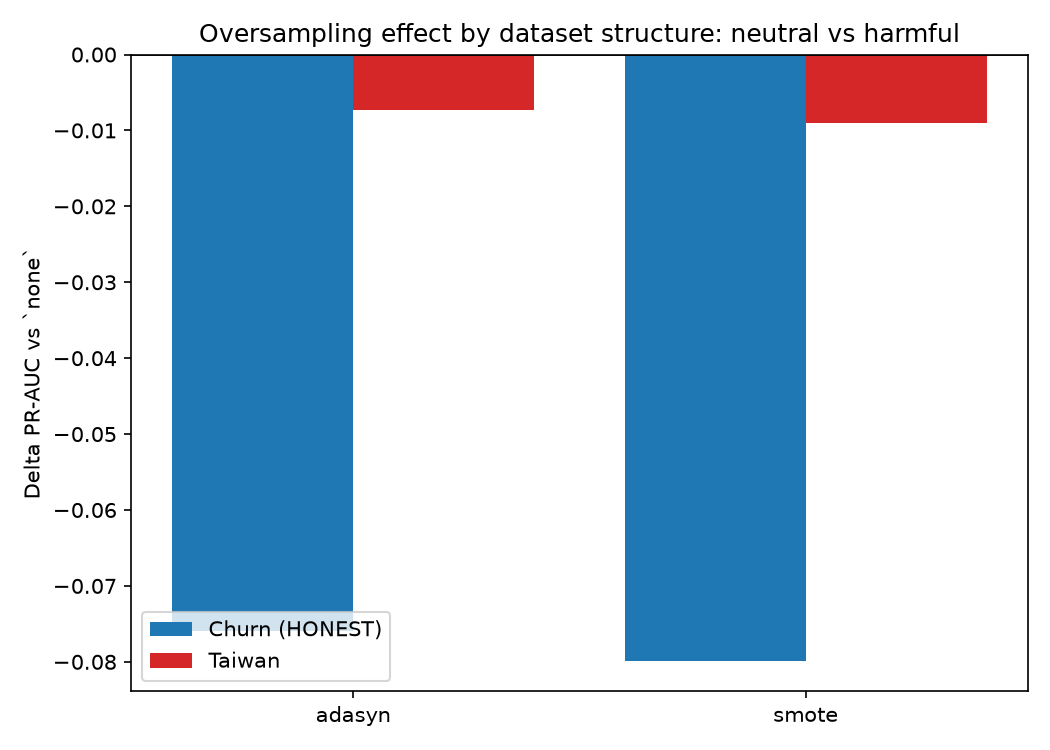

In [7]:
comparison_rows = []
for name in ["smote", "adasyn"]:
    comparison_rows.append(
        {"dataset": "Taiwan", "strategy": name, "mean_delta": sig_df.loc[name, "mean_delta"]}
    )
    comparison_rows.append(
        {
            "dataset": "Churn (HONEST)",
            "strategy": name,
            "mean_delta": churn_sig_df.loc[name, "mean_delta"],
        }
    )
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

cross_fig_path = TAIWAN_FIGURES_DIR / "cross_dataset_delta_pr_auc.png"
plot_cross_dataset_delta_bar(comparison_df, cross_fig_path, baseline_name="none")
display(Image(filename=str(cross_fig_path)))

## 5. Interpretation

In [8]:
none_pr = summary_df.loc["none", "pr_auc_mean"]
smote_pr = summary_df.loc["smote", "pr_auc_mean"]
adasyn_pr = summary_df.loc["adasyn", "pr_auc_mean"]

taiwan_smote_delta = sig_df.loc["smote", "mean_delta"]
taiwan_adasyn_delta = sig_df.loc["adasyn", "mean_delta"]
taiwan_smote_wilcoxon = sig_df.loc["smote", "wilcoxon_p"]
taiwan_adasyn_wilcoxon = sig_df.loc["adasyn", "wilcoxon_p"]

churn_smote_delta = churn_sig_df.loc["smote", "mean_delta"]
churn_adasyn_delta = churn_sig_df.loc["adasyn", "mean_delta"]

interpretation = f"""
On this cross-sectional dataset, oversampling is **neutral**, not harmful: `smote` PR-AUC={smote_pr:.4f} and `adasyn` PR-AUC={adasyn_pr:.4f} are both within a few thousandths of `none`'s {none_pr:.4f} (delta={taiwan_smote_delta:.4f} and {taiwan_adasyn_delta:.4f} respectively), and neither difference is statistically significant (Wilcoxon p={taiwan_smote_wilcoxon:.4f} and {taiwan_adasyn_wilcoxon:.4f}).

Contrast this with the churn panel's honest window (notebook 02): there, `smote` and `adasyn` deltas were {churn_smote_delta:.4f} and {churn_adasyn_delta:.4f} ? an order of magnitude larger, and highly significant (Wilcoxon p < 0.002 for both).

The same resampling method and model family give qualitatively different ranking outcomes on these two datasets. The cross-sectional-vs-panel difference is a plausible demarcation hypothesis, but later mechanism probes (notebooks 04?06) show that the specific temporal-incoherence/jaggedness story was disconfirmed and that controlled C2ST detectability is inconclusive. The mechanism remains open.
"""
display(Markdown(interpretation))


On this cross-sectional dataset, oversampling is **neutral**, not harmful: `smote` PR-AUC=0.4896 and `adasyn` PR-AUC=0.4914 are both within a few thousandths of `none`'s 0.4987 (delta=-0.0091 and -0.0073 respectively), and neither difference is statistically significant (Wilcoxon p=0.2769 and 0.2769).

Contrast this with the churn panel's honest window (notebook 02): there, `smote` and `adasyn` deltas were -0.0799 and -0.0760 ? an order of magnitude larger, and highly significant (Wilcoxon p < 0.002 for both).

The same resampling method and model family give qualitatively different ranking outcomes on these two datasets. The cross-sectional-vs-panel difference is a plausible demarcation hypothesis, but later mechanism probes (notebooks 04?06) show that the specific temporal-incoherence/jaggedness story was disconfirmed and that controlled C2ST detectability is inconclusive. The mechanism remains open.


## 6. Verification report

In [9]:
import hashlib
import inspect
import platform

import imblearn
import matplotlib
import scipy
import sklearn

from src.evaluation.cv import _repeated_cv_from_arrays
from src.evaluation.leakage_demo import leaky_vs_honest_smote as _leaky_vs_honest_smote_fn


def _df_to_md_table(frame: pd.DataFrame, float_format: str = "{:.6f}") -> str:
    """Render a small DataFrame as a GitHub-flavored markdown table."""
    header = "| " + " | ".join(frame.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(frame.columns)) + " |"
    lines = [header, sep]
    for _, row in frame.iterrows():
        row_cells = []
        for value in row:
            row_cells.append(
                float_format.format(value) if isinstance(value, float) else str(value)
            )
        lines.append("| " + " | ".join(row_cells) + " |")
    return "\n".join(lines)

In [10]:
raw_bytes = taiwan_path.read_bytes()
file_sha256_12 = hashlib.sha256(raw_bytes).hexdigest()[:12]
n_rows = len(X)
n_features = X.shape[1]
positive_rate = float(y.mean())

smote_within_band = abs(smote_pr - none_pr) <= 0.03
adasyn_within_band = abs(adasyn_pr - none_pr) <= 0.03
wilcoxon_neutral = bool(
    sig_df.loc["smote", "wilcoxon_p"] > 0.05 and sig_df.loc["adasyn", "wilcoxon_p"] > 0.05
)

checks = [
    {
        "check": "Dataset: n_rows in [6800, 6840]",
        "measured": f"{n_rows}",
        "target": "[6800, 6840]",
        "passed": bool(6800 <= n_rows <= 6840),
    },
    {
        "check": "Dataset: positive_rate in [0.030, 0.035]",
        "measured": f"{positive_rate:.6f}",
        "target": "[0.030, 0.035]",
        "passed": bool(0.030 <= positive_rate <= 0.035),
    },
    {
        "check": "E1: leaky PR-AUC >= 0.95",
        "measured": f"{e1_result['leaky_pr_auc']:.6f}",
        "target": ">= 0.95",
        "passed": bool(e1_result["leaky_pr_auc"] >= 0.95),
    },
    {
        "check": "E1: honest PR-AUC in [0.38, 0.50]",
        "measured": f"{e1_result['honest_pr_auc']:.6f}",
        "target": "[0.38, 0.50]",
        "passed": bool(0.38 <= e1_result["honest_pr_auc"] <= 0.50),
    },
    {
        "check": "E1: inflation >= 0.45",
        "measured": f"{e1_result['inflation']:.6f}",
        "target": ">= 0.45",
        "passed": bool(e1_result["inflation"] >= 0.45),
    },
    {
        "check": "E2: none PR-AUC in [0.38, 0.50]",
        "measured": f"{none_pr:.6f}",
        "target": "[0.38, 0.50]",
        "passed": bool(0.38 <= none_pr <= 0.50),
    },
    {
        "check": (
            "E2: smote & adasyn PR-AUC each within +/-0.03 of none, AND "
            "wilcoxon_p > 0.05 for both"
        ),
        "measured": (
            f"|smote-none|={abs(smote_pr - none_pr):.6f}, "
            f"|adasyn-none|={abs(adasyn_pr - none_pr):.6f}, "
            f"wilcoxon_p(smote)={sig_df.loc['smote', 'wilcoxon_p']:.6f}, "
            f"wilcoxon_p(adasyn)={sig_df.loc['adasyn', 'wilcoxon_p']:.6f}"
        ),
        "target": "both within 0.03 AND wilcoxon_p(smote)>0.05 AND wilcoxon_p(adasyn)>0.05",
        "passed": bool(smote_within_band and adasyn_within_band and wilcoxon_neutral),
    },
]
for c in checks:
    c["result"] = "PASS" if c["passed"] else "FAIL"
    print(f"[{c['result']}] {c['check']} | measured: {c['measured']} | target: {c['target']}")

[PASS] Dataset: n_rows in [6800, 6840] | measured: 6819 | target: [6800, 6840]
[PASS] Dataset: positive_rate in [0.030, 0.035] | measured: 0.032263 | target: [0.030, 0.035]
[PASS] E1: leaky PR-AUC >= 0.95 | measured: 0.999577 | target: >= 0.95
[PASS] E1: honest PR-AUC in [0.38, 0.50] | measured: 0.484579 | target: [0.38, 0.50]
[PASS] E1: inflation >= 0.45 | measured: 0.514998 | target: >= 0.45
[PASS] E2: none PR-AUC in [0.38, 0.50] | measured: 0.498675 | target: [0.38, 0.50]
[PASS] E2: smote & adasyn PR-AUC each within +/-0.03 of none, AND wilcoxon_p > 0.05 for both | measured: |smote-none|=0.009065, |adasyn-none|=0.007265, wilcoxon_p(smote)=0.276855, wilcoxon_p(adasyn)=0.276855 | target: both within 0.03 AND wilcoxon_p(smote)>0.05 AND wilcoxon_p(adasyn)>0.05


In [11]:
leaky_vs_honest_source = inspect.getsource(_leaky_vs_honest_smote_fn)
core_loop_source = inspect.getsource(_repeated_cv_from_arrays)

checks_table = pd.DataFrame(
    [
        {"check": c["check"], "measured": c["measured"], "target": c["target"], "result": c["result"]}
        for c in checks
    ]
)

raw_e2_json = json.dumps(summary_df.to_dict(orient="index"), indent=2)
raw_sig_json = json.dumps(sig_df.reset_index().to_dict(orient="records"), indent=2)

report_lines = [
    "# 03 \u2014 Taiwan Bankruptcy Replication Verification Report",
    "",
    "## Environment",
    f"- Python: {platform.python_version()}",
    f"- numpy: {np.__version__}",
    f"- pandas: {pd.__version__}",
    f"- scikit-learn: {sklearn.__version__}",
    f"- imbalanced-learn: {imblearn.__version__}",
    f"- scipy: {scipy.__version__}",
    f"- matplotlib: {matplotlib.__version__}",
    f"- Seed: {SEED}",
    "",
    "## Dataset fingerprint",
    f"- Source: {taiwan_path}",
    f"- n_rows: {n_rows:,}",
    f"- n_features: {n_features}",
    f"- positive_rate: {positive_rate:.6f}",
    f"- sha256(first 12 chars): {file_sha256_12}",
    "",
    "## E1 table (leaky vs honest SMOTE)",
    f"- leaky_pr_auc: {e1_result['leaky_pr_auc']:.6f}",
    f"- honest_pr_auc: {e1_result['honest_pr_auc']:.6f}",
    f"- inflation: {e1_result['inflation']:.6f}",
    "",
    "## E2 table (mean +/- std, full precision)",
    "",
    _df_to_md_table(formatted_summary.reset_index(), float_format="{}"),
    "",
    "Raw JSON:",
    "```json",
    raw_e2_json,
    "```",
    "",
    "## Paired significance vs `none` (PR-AUC)",
    "",
    _df_to_md_table(sig_df.reset_index()),
    "",
    "Raw JSON:",
    "```json",
    raw_sig_json,
    "```",
    "",
    "## Inline source",
    "",
    "### leaky_vs_honest_smote (src/evaluation/leakage_demo.py)",
    "```python",
    leaky_vs_honest_source,
    "```",
    "",
    "### Core per-fold loop used for E2 (_repeated_cv_from_arrays, src/evaluation/cv.py)",
    "```python",
    core_loop_source,
    "```",
    "",
    "## Self-run acceptance checks",
    _df_to_md_table(checks_table, float_format="{}"),
    "",
]
report_text = "\n".join(report_lines)

report_path = OUTPUT_DIR / "03_taiwan_replication_verification.md"
report_path.write_text(report_text, encoding="utf-8")
print(report_text)

# 03 - Taiwan Bankruptcy Replication Verification Report

## Environment
- Python: 3.12.3
- numpy: 2.4.6
- pandas: 3.0.3
- scikit-learn: 1.9.0
- imbalanced-learn: 0.14.2
- scipy: 1.18.0
- matplotlib: 3.11.0
- Seed: 42

## Dataset fingerprint
- Source: C:\Users\hpdk1\Documents\Projects\thesis-recreation-2026\data\raw\taiwan_bankruptcy.csv
- n_rows: 6,819
- n_features: 95
- positive_rate: 0.032263
- sha256(first 12 chars): cbe49e73a9df

## E1 table (leaky vs honest SMOTE)
- leaky_pr_auc: 0.999577
- honest_pr_auc: 0.484579
- inflation: 0.514998

## E2 table (mean +/- std, full precision)

| strategy | pr_auc | roc_auc | recall_at_10pct | brier |
| --- | --- | --- | --- | --- |
| none | 0.498675 ± 0.059632 | 0.936457 ± 0.016739 | 0.772727 ± 0.064282 | 0.025287 ± 0.001995 |
| class_weight | 0.507538 ± 0.068168 | 0.934793 ± 0.016705 | 0.766667 ± 0.075116 | 0.024673 ± 0.003254 |
| random_over | 0.489699 ± 0.075507 | 0.936505 ± 0.016509 | 0.774242 ± 0.063396 | 0.025730 ± 0.003804 |
| smote | 0